In [ ]:
import json
import re
import time
import pandas as pd
from openai import OpenAI
from tqdm import tqdm

import os

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)
MODELS = {
    "llama70b": "llama-3.3-70b-versatile",
    "llama8b": "llama-3.1-8b-instant",
    "qwen32b": "qwen/qwen3-32b"
}

MODELS_TO_TEST = list(MODELS.keys())

print("Configuration OK")
print("Modèles disponibles :", list(MODELS.keys()))

Configuration OK
Modèles disponibles : ['llama70b', 'llama8b', 'qwen32b']


In [19]:
# Test simple

test_text = "Your account has been suspended. Click here immediately to reactivate it."

for model_name in MODELS_TO_TEST:

    print(f"\n{'='*60}")
    print(f"Test avec : {model_name}")
    print("Modèle :", MODELS[model_name])

    try:
        response = client.chat.completions.create(
            model=MODELS[model_name],
            messages=[
                {
                    "role": "user",
                    "content": f"""
Classify this message as phishing or legitimate.

Message:
{test_text}

Respond ONLY with JSON:
{{"label":"phishing|legitimate","confidence":"high|medium|low"}}
"""
                }
            ],
            temperature=0,
            max_tokens=100
        )

        print(response.choices[0].message.content)

    except Exception as e:
        print("ERREUR :", e)


Test avec : llama70b
Modèle : llama-3.3-70b-versatile
{"label":"phishing","confidence":"high"}

Test avec : llama8b
Modèle : llama-3.1-8b-instant
{"label":"phishing","confidence":"high"}

Test avec : qwen32b
Modèle : qwen/qwen3-32b
<think>
Okay, let's see. The user wants me to classify this message as phishing or legitimate. The message says, "Your account has been suspended. Click here immediately to reactivate it." Hmm.

First, I remember that phishing messages often create a sense of urgency to trick people into clicking links. This message uses "immediately," which is a red flag. Also, legitimate companies usually have more formal language and might include specific details like account numbers or a proper support contact method. This


In [20]:
# Chargement du dataset

df = pd.read_excel("master_dataset_preprocessed.xlsx", header=1)

print("Colonnes :", df.columns.tolist())
print("Shape    :", df.shape)

print("\nDistribution labels :")
print(df['label'].value_counts())

print("\nDistribution langues :")
if 'language' in df.columns:
    print(df['language'].value_counts())

# Échantillon équilibré : 50 phishing + 50 legitimate
sample = (
    df.groupby('label', group_keys=False)
      .sample(n=50, random_state=42)
      .reset_index(drop=True)
)

print("\nÉchantillon sélectionné :")
print(sample['label'].value_counts())

sample.head(3)

Colonnes : ['text', 'sender', 'label', 'channel', 'language', 'attack_type', 'risk_level', 'preprocessed_text']
Shape    : (3038, 8)

Distribution labels :
label
legitimate    1679
phishing      1359
Name: count, dtype: int64

Distribution langues :
language
en    1508
ar     899
fr     631
Name: count, dtype: int64

Échantillon sélectionné :
label
legitimate    50
phishing      50
Name: count, dtype: int64


,text,sender,label,channel,language,attack_type,risk_level,preprocessed_text
0,منشورك على لابوست المغرب تلقى تفاعلات جديدة.,NaN,legitimate,social_media,ar,none,low,منشورك لابوست المغرب تلقى تفاعلات جديدة.
1,Notification: code 541500 ou RDV/commande conf...,Microsoft,legitimate,sms,en,none,low,notification: code 541500 ou rdv/commande conf...
2,"Bonjour, Je vous communique ci-joint le résult...",r.hanbali@uca.ma,legitimate,email,fr,none,low,"bonjour, communique ci-joint résultat avant ra..."


In [22]:
def clean_json_response(raw: str) -> str:
    """
    Extrait le JSON de la réponse brute du LLM.
    Gère :
    - <think>...</think>
    - ```json ... ```
    - texte parasite avant/après
    """

    if not raw:
        return ""

    raw = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL)

    m = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', raw, re.DOTALL)
    if m:
        return m.group(1)

    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        return m.group(0)

    return raw.strip()


def classify_with_llm(text: str, model_key: str) -> dict:

    if model_key not in MODELS:
        return {
            "label": "error",
            "error_type": "KeyError",
            "raw_response": f"Modèle '{model_key}' introuvable"
        }

    prompt = f"""
You are a cybersecurity expert specialized in phishing detection.

Analyze the following message.

IMPORTANT:
- Return ONLY valid JSON.
- Do not explain your reasoning.
- Do not use <think>.
- Do not use markdown.
- Do not wrap JSON inside ```json blocks.

Required JSON format:

{{
  "label":"phishing|legitimate",
  "confidence":"low|medium|high",
  "risk_score":0-100,
  "attack_type":"credential theft|financial scam|malicious link|impersonation|none",
  "explanation":"one sentence explanation",
  "suspicious_elements":["item1","item2"],
  "recommendation":"recommended action"
}}

Message:
\"\"\"{text}\"\"\"
"""

    raw = ""

    try:

        response = client.chat.completions.create(
            model=MODELS[model_key],
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0,
            max_tokens=400
        )

        raw = response.choices[0].message.content or ""

        cleaned = clean_json_response(raw)

        parsed = json.loads(cleaned)

        # Normalisation robuste du label
        label = str(parsed.get("label", "unknown"))

        label = (
            label.replace('"', '')
                 .replace("'", "")
                 .strip()
                 .lower()
        )

        if "phishing" in label:
            label = "phishing"
        elif "legitimate" in label:
            label = "legitimate"
        else:
            label = "unknown"

        parsed["label"] = label
        parsed["raw_response"] = raw

        return parsed

    except json.JSONDecodeError:

        return {
            "label": "error",
            "error_type": "json_parse",
            "raw_response": raw
        }

    except Exception as e:

        return {
            "label": "error",
            "error_type": type(e).__name__,
            "raw_response": str(e)
        }


# Test rapide

for model_name in MODELS_TO_TEST:

    print("\n" + "=" * 60)
    print(f"Test avec : {model_name}")

    result = classify_with_llm(
        test_text,
        model_name
    )

    print(json.dumps(
        result,
        indent=2,
        ensure_ascii=False
    ))


Test avec : llama70b
{
  "label": "phishing",
  "confidence": "high",
  "risk_score": 90,
  "attack_type": "credential theft",
  "explanation": "The message attempts to create a sense of urgency to trick the user into clicking a malicious link",
  "suspicious_elements": [
    "urgency tactic",
    "vague threat",
    "suspicious link"
  ],
  "recommendation": "do not click the link and contact the account provider directly to verify the suspension",
  "raw_response": "{\n  \"label\":\"phishing\",\n  \"confidence\":\"high\",\n  \"risk_score\":90,\n  \"attack_type\":\"credential theft\",\n  \"explanation\":\"The message attempts to create a sense of urgency to trick the user into clicking a malicious link\",\n  \"suspicious_elements\":[\"urgency tactic\", \"vague threat\", \"suspicious link\"],\n  \"recommendation\":\"do not click the link and contact the account provider directly to verify the suspension\"\n}"
}

Test avec : llama8b
{
  "label": "phishing",
  "confidence": "high",
  "r

In [23]:
result = classify_with_llm(
    test_text,
    "qwen32b"
)

print(json.dumps(
    result,
    indent=2,
    ensure_ascii=False
))

{
  "label": "phishing",
  "confidence": "high",
  "risk_score": 85,
  "attack_type": "credential theft",
  "explanation": "The message uses urgency and a suspicious link to trick the user into taking action.",
  "suspicious_elements": [
    "Urgent language",
    "Suspicious link"
  ],
  "recommendation": "Do not click the link. Verify the sender and contact the service provider directly.",
  "raw_response": "<think>\n\n</think>\n\n{\n  \"label\":\"phishing\",\n  \"confidence\":\"high\",\n  \"risk_score\":85,\n  \"attack_type\":\"credential theft\",\n  \"explanation\":\"The message uses urgency and a suspicious link to trick the user into taking action.\",\n  \"suspicious_elements\":[\"Urgent language\",\"Suspicious link\"],\n  \"recommendation\":\"Do not click the link. Verify the sender and contact the service provider directly.\"\n}"
}


In [24]:
# Benchmark sur 100 exemples

sample = sample.head(100)

results = []

for model_name in MODELS_TO_TEST:

    print(f"\n{'─'*50}")
    print(f"Modèle : {model_name.upper()}")
    print(f"{'─'*50}")

    for _, row in tqdm(
        sample.iterrows(),
        total=len(sample),
        desc=model_name
    ):

        start = time.time()

        res = classify_with_llm(
            str(row['preprocessed_text']),
            model_name
        )

        elapsed = round(
            time.time() - start,
            2
        )

        results.append({
            "model": model_name,
            "true_label": str(row['label']).strip().lower(),
            "pred_label": res.get("label", "error"),
            "confidence": res.get("confidence", ""),
            "risk_score": res.get("risk_score", ""),
            "attack_type": res.get("attack_type", ""),
            "recommendation": res.get("recommendation", ""),
            "explanation": res.get("explanation", ""),
            "suspicious": str(
                res.get("suspicious_elements", [])
            ),
            "response_time": elapsed,
            "language": row["language"] if "language" in row else "unknown"
        })

results_df = pd.DataFrame(results)

print("\nBenchmark terminé !")
print(f"Total lignes : {len(results_df)}")

print("\nDistribution des prédictions :")
print(
    results_df.groupby(
        ["model", "pred_label"]
    ).size().unstack(fill_value=0)
)

results_df.head()


──────────────────────────────────────────────────
Modèle : LLAMA70B
──────────────────────────────────────────────────


llama70b: 100%|██████████| 100/100 [03:35<00:00,  2.15s/it]



──────────────────────────────────────────────────
Modèle : LLAMA8B
──────────────────────────────────────────────────


llama8b: 100%|██████████| 100/100 [04:14<00:00,  2.55s/it]



──────────────────────────────────────────────────
Modèle : QWEN32B
──────────────────────────────────────────────────


qwen32b: 100%|██████████| 100/100 [04:06<00:00,  2.47s/it]


Benchmark terminé !
Total lignes : 300

Distribution des prédictions :
pred_label  legitimate  phishing
model                           
llama70b            37        63
llama8b             25        75
qwen32b              6        94


,model,true_label,pred_label,confidence,risk_score,attack_type,recommendation,explanation,suspicious,response_time,language
0,llama70b,legitimate,legitimate,high,0,none,no action required,The message appears to be a simple statement i...,[],0.84,ar
1,llama70b,legitimate,phishing,high,80,impersonation,"do not respond or click on any links, verify t...",The message appears to be a brief and vague no...,"['lack of context', 'vague language']",0.80,en
2,llama70b,legitimate,legitimate,high,0,none,no action required,The message appears to be a genuine academic n...,[],0.67,fr
3,llama70b,legitimate,phishing,high,90,credential theft,do not enter the code and verify the request t...,The message is attempting to trick the user in...,"['single-use code request', 'vagueness about t...",0.69,en
4,llama70b,legitimate,legitimate,high,0,none,no action required,The message appears to be a legitimate URL fro...,[],0.47,en


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

summary_rows = []

for model in MODELS_TO_TEST:

    subset = results_df[
        results_df['model'] == model
    ].copy()

    valid = subset[
        subset['pred_label'].isin(
            ['phishing', 'legitimate']
        )
    ]

    n_total = len(subset)
    n_valid = len(valid)
    n_error = n_total - n_valid

    print(f"\n{'='*52}")
    print(f"Modèle : {model.upper()}")
    print(f"Valides : {n_valid}/{n_total} | Erreurs : {n_error}")
    print(f"{'='*52}")

    if n_valid == 0:
        continue

    acc = accuracy_score(
        valid['true_label'],
        valid['pred_label']
    )

    precision = precision_score(
        valid['true_label'],
        valid['pred_label'],
        pos_label='phishing',
        zero_division=0
    )

    recall = recall_score(
        valid['true_label'],
        valid['pred_label'],
        pos_label='phishing',
        zero_division=0
    )

    f1_ph = f1_score(
        valid['true_label'],
        valid['pred_label'],
        pos_label='phishing',
        zero_division=0
    )

    f1_leg = f1_score(
        valid['true_label'],
        valid['pred_label'],
        pos_label='legitimate',
        zero_division=0
    )

    f1_macro = f1_score(
        valid['true_label'],
        valid['pred_label'],
        average='macro',
        zero_division=0
    )

    avg_time = valid['response_time'].mean()

    print(f"Accuracy            : {acc:.2%}")
    print(f"Precision           : {precision:.2%}")
    print(f"Recall              : {recall:.2%}")
    print(f"F1 Phishing         : {f1_ph:.2%}")
    print(f"F1 Legitimate       : {f1_leg:.2%}")
    print(f"F1 Macro            : {f1_macro:.2%}")
    print(f"Temps moyen         : {avg_time:.2f}s")

    print("\nClassification Report:")
    print(
        classification_report(
            valid['true_label'],
            valid['pred_label'],
            zero_division=0
        )
    )

    summary_rows.append({
        "Model": model,
        "Accuracy": round(acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1_Phishing": round(f1_ph, 4),
        "F1_Legitimate": round(f1_leg, 4),
        "F1_Macro": round(f1_macro, 4),
        "Avg_Time": round(avg_time, 2),
        "Valid": n_valid,
        "Errors": n_error
    })

benchmark_summary = pd.DataFrame(summary_rows)

print("\nRésumé final :")
print(benchmark_summary)

# Sauvegarde
benchmark_summary.to_csv(
    "benchmark_summary.csv",
    index=False
)

results_df.to_csv(
    "benchmark_predictions.csv",
    index=False
)

print("\nFichiers sauvegardés :")
print("- benchmark_summary.csv")
print("- benchmark_predictions.csv")


Modèle : LLAMA70B
Valides : 100/100 | Erreurs : 0
Accuracy            : 77.00%
Precision           : 71.43%
Recall              : 90.00%
F1 Phishing         : 79.65%
F1 Legitimate       : 73.56%
F1 Macro            : 76.60%
Temps moyen         : 2.15s

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.86      0.64      0.74        50
    phishing       0.71      0.90      0.80        50

    accuracy                           0.77       100
   macro avg       0.79      0.77      0.77       100
weighted avg       0.79      0.77      0.77       100


Modèle : LLAMA8B
Valides : 100/100 | Erreurs : 0
Accuracy            : 71.00%
Precision           : 64.00%
Recall              : 96.00%
F1 Phishing         : 76.80%
F1 Legitimate       : 61.33%
F1 Macro            : 69.07%
Temps moyen         : 2.55s

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.92      0.46      0.61        50
    phishin

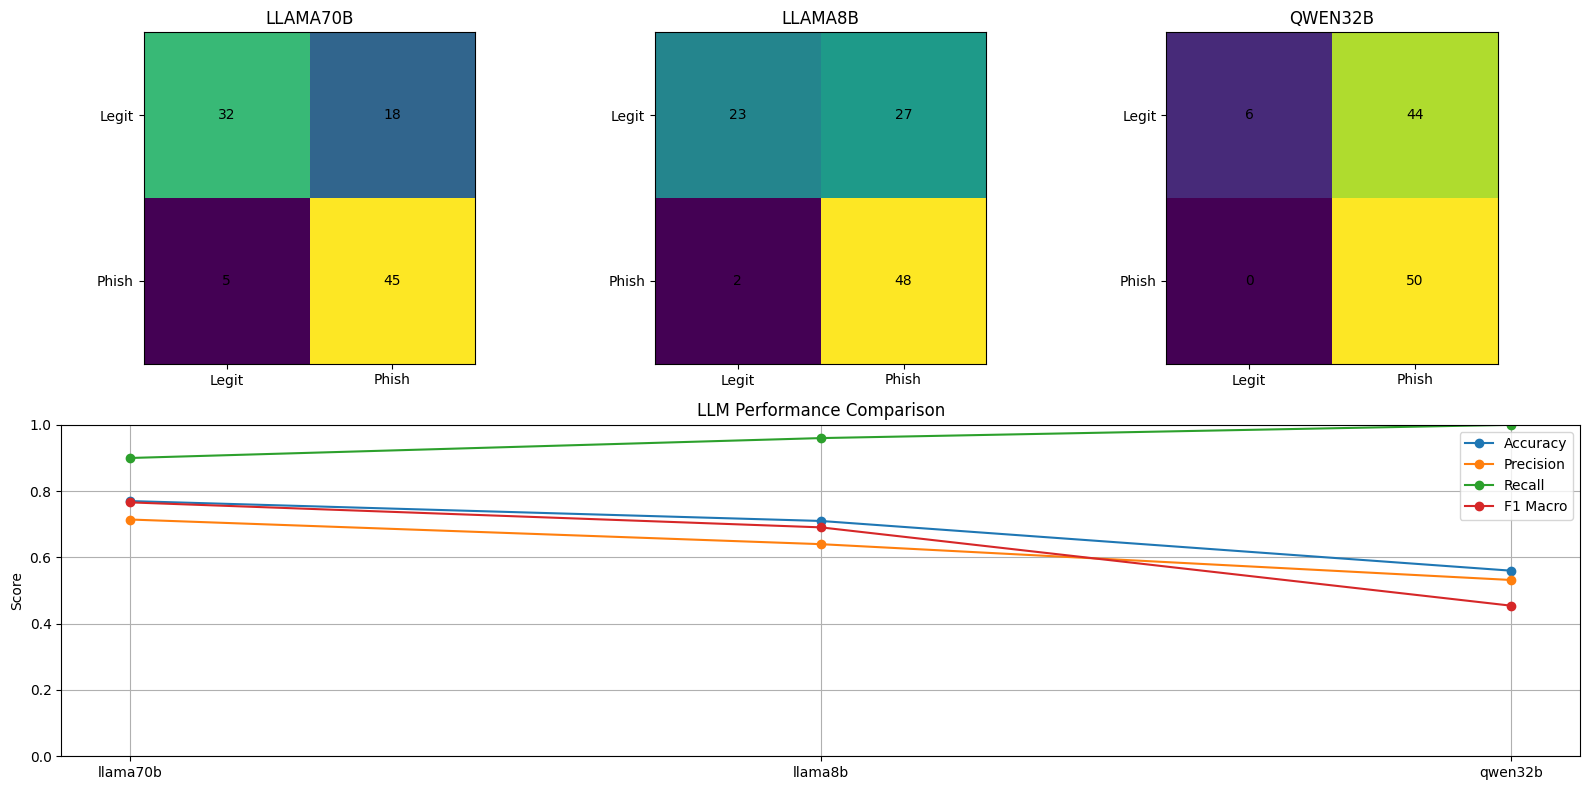

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

n_models = len(MODELS_TO_TEST)

plt.figure(figsize=(16, 8))

# =========================
# Matrices de confusion
# =========================

for idx, model in enumerate(MODELS_TO_TEST):

    ax = plt.subplot(2, n_models, idx + 1)

    valid = results_df[
        (results_df["model"] == model) &
        (results_df["pred_label"].isin(["phishing", "legitimate"]))
    ]

    if len(valid) == 0:
        ax.set_visible(False)
        continue

    cm = confusion_matrix(
        valid["true_label"],
        valid["pred_label"],
        labels=["legitimate", "phishing"]
    )

    ax.imshow(cm)

    ax.set_title(model.upper())

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Legit", "Phish"])
    ax.set_yticklabels(["Legit", "Phish"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

# =========================
# Comparaison des modèles
# =========================

ax4 = plt.subplot(2, 1, 2)

ax4.plot(
    benchmark_summary["Model"],
    benchmark_summary["Accuracy"],
    marker="o",
    label="Accuracy"
)

ax4.plot(
    benchmark_summary["Model"],
    benchmark_summary["Precision"],
    marker="o",
    label="Precision"
)

ax4.plot(
    benchmark_summary["Model"],
    benchmark_summary["Recall"],
    marker="o",
    label="Recall"
)

ax4.plot(
    benchmark_summary["Model"],
    benchmark_summary["F1_Macro"],
    marker="o",
    label="F1 Macro"
)

ax4.set_title("LLM Performance Comparison")

ax4.set_ylabel("Score")
ax4.set_ylim(0, 1)

ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import accuracy_score, f1_score

language_results = []

for model in MODELS_TO_TEST:

    for lang in sorted(results_df["language"].unique()):

        subset = results_df[
            (results_df["model"] == model) &
            (results_df["language"] == lang)
        ]

        valid = subset[
            subset["pred_label"].isin(
                ["phishing", "legitimate"]
            )
        ]

        if len(valid) == 0:
            continue

        acc = accuracy_score(
            valid["true_label"],
            valid["pred_label"]
        )

        f1 = f1_score(
            valid["true_label"],
            valid["pred_label"],
            average="macro",
            zero_division=0
        )

        language_results.append({
            "Model": model,
            "Language": lang,
            "Samples": len(valid),
            "Accuracy": round(acc, 4),
            "F1_Macro": round(f1, 4)
        })

language_summary = pd.DataFrame(language_results)

print(language_summary)

language_summary.to_csv(
    "benchmark_by_language.csv",
    index=False
)

      Model Language  Samples  Accuracy  F1_Macro
0  llama70b       ar       30    0.7667    0.7600
1  llama70b       en       55    0.8182    0.7935
2  llama70b       fr       15    0.6000    0.5982
3   llama8b       ar       30    0.5667    0.5543
4   llama8b       en       55    0.8364    0.8114
5   llama8b       fr       15    0.5333    0.5333
6   qwen32b       ar       30    0.4000    0.3250
7   qwen32b       en       55    0.7091    0.5736
8   qwen32b       fr       15    0.3333    0.3056
